# ResumeMatch AI: An NLP-Based Resume and Job Matching System

## Project Overview

ResumeMatch AI is an Natural Language Processing (NLP) based system designed to analyze resumes and identify suitable job roles.

The system processes resume text using text preprocessing and converts the text into numerical representations using TF-IDF (Term Frequency-Inverse Document Frequency). Cosine Similarity is then used to measure the similarity between a resume and different job descriptions.

The system also identifies matching keywords and potential missing skills and recommends the most suitable job role based on the similarity score.

## Objectives

- Analyze and preprocess resume text.
- Apply NLP techniques to resume data.
- Convert text into numerical vectors using TF-IDF.
- Calculate similarity between resumes and job descriptions.
- Identify matching and missing skills.
- Recommend suitable job roles.
- Visualize the analysis results.

## NLP Techniques Used

1. Text Preprocessing
2. Tokenization
3. Stop-word Removal
4. TF-IDF Vectorization
5. Cosine Similarity
6. Keyword Matching

## Dataset

The project uses a resume dataset containing approximately 2,484 resumes with resume text and corresponding categories.

## Workflow

Resume Dataset  
↓  
Text Preprocessing  
↓  
TF-IDF Vectorization  
↓  
Job Description Processing  
↓  
Cosine Similarity  
↓  
Resume-Job Matching  
↓  
Skill Analysis  
↓  
Job Recommendation

In [58]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vishwakkanna\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vishwakkanna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vishwakkanna\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [59]:
df = pd.read_csv("Resume.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [60]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nResume categories:")
print(df["Category"].value_counts())

Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Resume categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


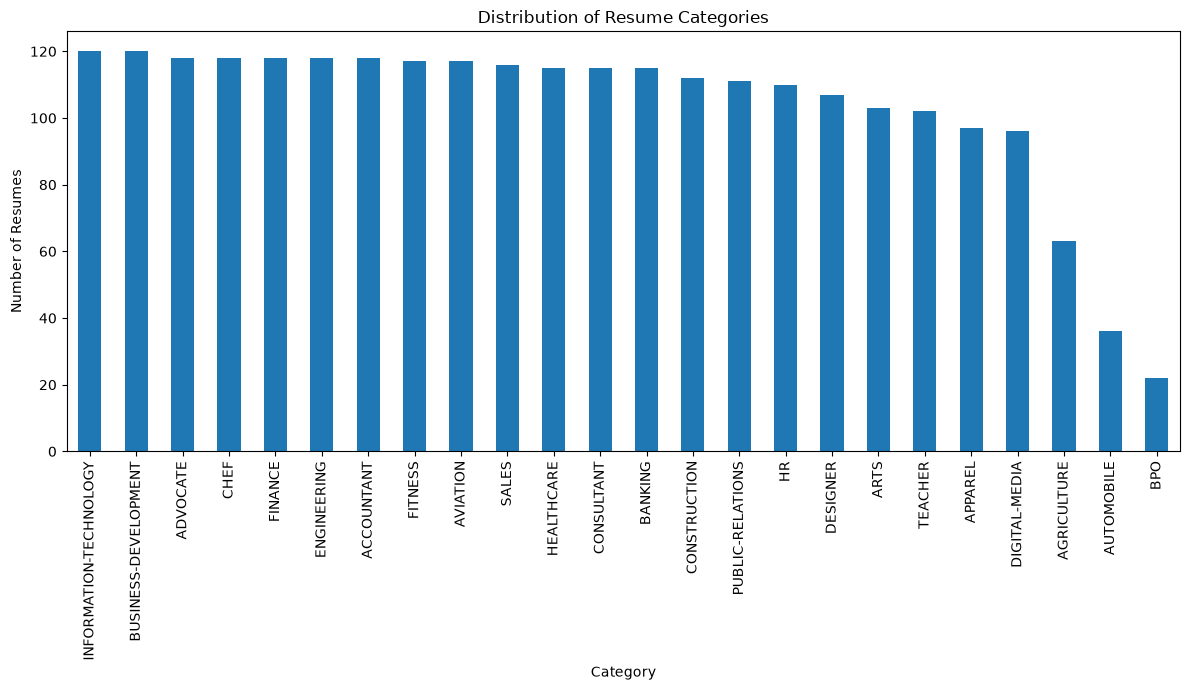

In [61]:
plt.figure(figsize=(12, 7))

df["Category"].value_counts().plot(kind="bar")

plt.title("Distribution of Resume Categories")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show() 

In [62]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

df["Clean_Resume"] = df["Resume_str"].fillna("").apply(clean_text)

print("Preprocessing completed!")

Preprocessing completed!


In [63]:
print("Original:")
print(df["Resume_str"].iloc[0][:1000])

print("\n" + "=" * 80 + "\n")

print("Cleaned:")
print(df["Clean_Resume"].iloc[0][:1000])

Original:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, 

In [64]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df["Clean_Resume"]
)

print("TF-IDF completed!")
print("Matrix shape:", tfidf_matrix.shape)

TF-IDF completed!
Matrix shape: (2484, 5000)


In [65]:
job_descriptions = {

    "Python Developer": """
    Python programming Django Flask FastAPI
    object oriented programming data structures algorithms
    SQL APIs Git software development debugging
    backend development
    """,

    "Data Analyst": """
    Python SQL Excel Power BI Tableau
    data analysis statistics pandas numpy
    data visualization dashboards reporting
    business intelligence
    """,

    "Web Developer": """
    HTML CSS JavaScript React frontend development
    responsive web design APIs Git
    user interface web development
    """,

    "Machine Learning Engineer": """
    Python machine learning deep learning
    artificial intelligence TensorFlow PyTorch
    scikit learn pandas numpy data science
    algorithms model training
    """,

    "Software Engineer": """
    Java Python C++ data structures algorithms
    object oriented programming SQL Git
    software development testing debugging
    problem solving
    """
}

job_descriptions

{'Python Developer': '\n    Python programming Django Flask FastAPI\n    object oriented programming data structures algorithms\n    SQL APIs Git software development debugging\n    backend development\n    ',
 'Data Analyst': '\n    Python SQL Excel Power BI Tableau\n    data analysis statistics pandas numpy\n    data visualization dashboards reporting\n    business intelligence\n    ',
 'Web Developer': '\n    HTML CSS JavaScript React frontend development\n    responsive web design APIs Git\n    user interface web development\n    ',
 'Machine Learning Engineer': '\n    Python machine learning deep learning\n    artificial intelligence TensorFlow PyTorch\n    scikit learn pandas numpy data science\n    algorithms model training\n    ',
 'Software Engineer': '\n    Java Python C++ data structures algorithms\n    object oriented programming SQL Git\n    software development testing debugging\n    problem solving\n    '}

In [66]:
all_documents = (
    list(df["Clean_Resume"])
    + list(job_descriptions.values())
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

all_tfidf = vectorizer.fit_transform(all_documents)

resume_vectors = all_tfidf[:len(df)]
job_vectors = all_tfidf[len(df):]

print("Resume vectors:", resume_vectors.shape)
print("Job vectors:", job_vectors.shape)

Resume vectors: (2484, 5000)
Job vectors: (5, 5000)


In [67]:
resume_index = 0

resume_vector = resume_vectors[resume_index]

similarity_scores = cosine_similarity(
    resume_vector,
    job_vectors
)[0]

results = pd.DataFrame({
    "Job Role": list(job_descriptions.keys()),
    "Match Score (%)": similarity_scores * 100
})

results = results.sort_values(
    "Match Score (%)",
    ascending=False
).reset_index(drop=True)

results

,Job Role,Match Score (%)
0,Data Analyst,7.704032
1,Python Developer,2.683608
2,Software Engineer,1.553281
3,Machine Learning Engineer,1.106528
4,Web Developer,0.556906


In [68]:
best_match = results.iloc[0]

print("Resume Category:")
print(df.iloc[resume_index]["Category"])

print("\nRecommended Job Role:")
print(best_match["Job Role"])

print("\nMatch Score:")
print(f"{best_match['Match Score (%)']:.2f}%")

Resume Category:
HR

Recommended Job Role:
Data Analyst

Match Score:
7.70%


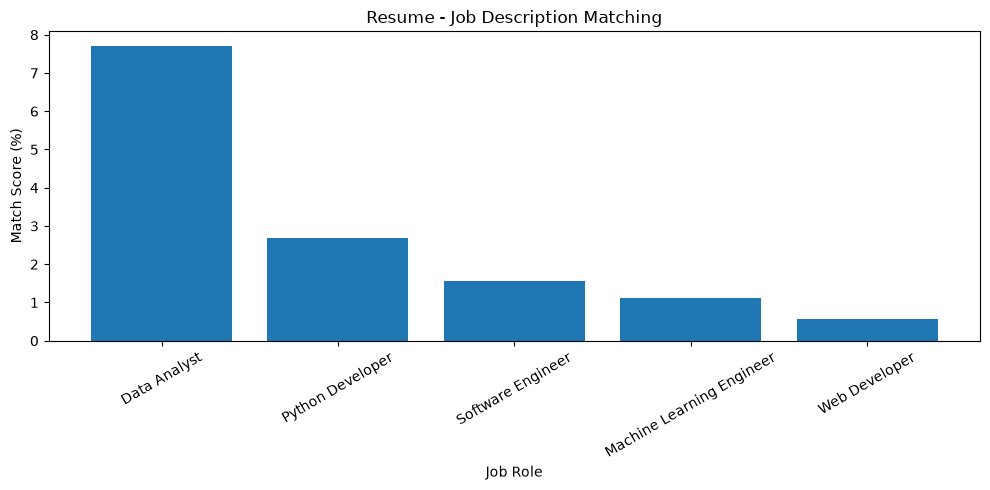

In [69]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Job Role"],
    results["Match Score (%)"]
)

plt.title("Resume - Job Description Matching")
plt.xlabel("Job Role")
plt.ylabel("Match Score (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [70]:
def get_keywords(text):
    text = clean_text(text)
    return set(text.split())


resume_keywords = get_keywords(
    df.iloc[resume_index]["Resume_str"]
)

selected_job = results.iloc[0]["Job Role"]

job_keywords = get_keywords(
    job_descriptions[selected_job]
)

matching_keywords = sorted(
    resume_keywords.intersection(job_keywords)
)

missing_keywords = sorted(
    job_keywords.difference(resume_keywords)
)

print("Recommended Role:", selected_job)

print("\nMatching Skills:")
print(", ".join(matching_keywords))

print("\nPotential Missing Skills:")
print(", ".join(missing_keywords))

Recommended Role: Data Analyst

Matching Skills:
analysis, business, data, reporting, statistics

Potential Missing Skills:
dashboards, excel, intelligence, numpy, pandas, power, python, sql, tableau, visualization


In [71]:
test_results = []

for i in range(min(20, len(df))):

    resume_vector = resume_vectors[i]

    scores = cosine_similarity(
        resume_vector,
        job_vectors
    )[0]

    best_index = np.argmax(scores)

    test_results.append({
        "Resume Index": i,
        "Actual Category": df.iloc[i]["Category"],
        "Recommended Role": list(job_descriptions.keys())[best_index],
        "Match Score (%)": round(scores[best_index] * 100, 2)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Resume Index,Actual Category,Recommended Role,Match Score (%)
0,0,HR,Data Analyst,7.70
1,1,HR,Web Developer,6.97
2,2,HR,Web Developer,4.22
3,3,HR,Data Analyst,1.07
4,4,HR,Python Developer,3.35
5,5,HR,Machine Learning Engineer,1.66
6,6,HR,Web Developer,10.87
7,7,HR,Machine Learning Engineer,1.94
8,8,HR,Machine Learning Engineer,3.38
9,9,HR,Data Analyst,1.66


In [72]:
print("=" * 60)
print("              RESUMEMATCH AI")
print("=" * 60)

print("\nTotal Resumes Analyzed:", len(df))

print("\nNLP Techniques Used:")
print("1. Text Preprocessing")
print("2. TF-IDF Vectorization")
print("3. Cosine Similarity")

print("\nJob Roles:")
for role in job_descriptions:
    print("-", role)

print("\nObjective:")
print("To analyze resumes and recommend suitable job roles")
print("using NLP-based text similarity.")

              RESUMEMATCH AI

Total Resumes Analyzed: 2484

NLP Techniques Used:
1. Text Preprocessing
2. TF-IDF Vectorization
3. Cosine Similarity

Job Roles:
- Python Developer
- Data Analyst
- Web Developer
- Machine Learning Engineer
- Software Engineer

Objective:
To analyze resumes and recommend suitable job roles
using NLP-based text similarity.


In [73]:
test_results_df.to_csv(
    "Resume_Matching_Results.csv",
    index=False
)

print("Results saved as Resume_Matching_Results.csv")

Results saved as Resume_Matching_Results.csv


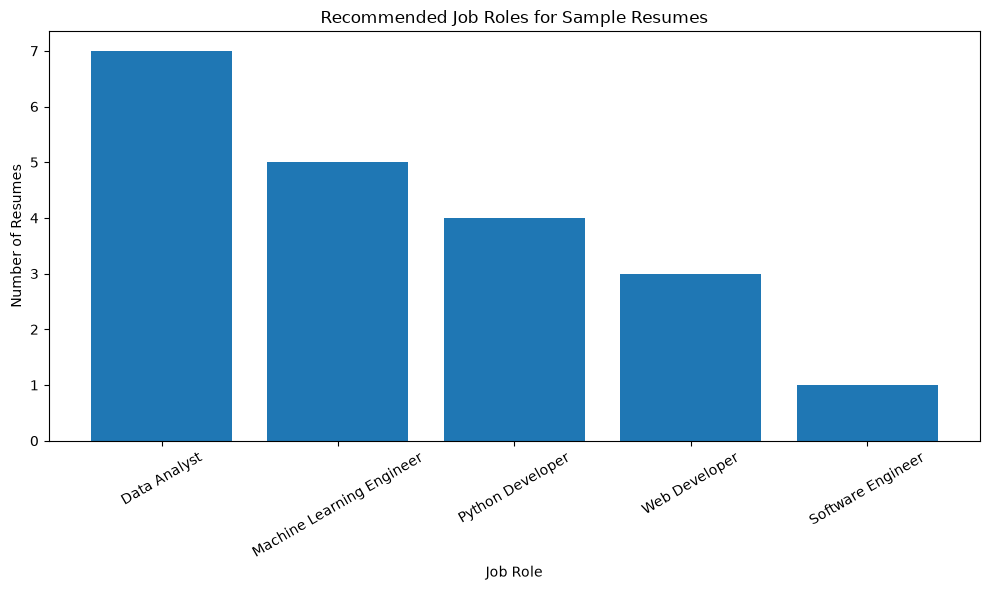

In [74]:
plt.figure(figsize=(10, 6))

plt.bar(
    test_results_df["Recommended Role"].value_counts().index,
    test_results_df["Recommended Role"].value_counts().values
)

plt.title("Recommended Job Roles for Sample Resumes")
plt.xlabel("Job Role")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()